# Figure 3.

| Author  | Stanley A. Baronett  |
|---------|----------------------|
| Created |  03/04/2026          |
| Updated |  03/04/2026          |

Similar to Figure 2 except until $t_\mathrm{lim} = 100T$.
The lower panel shows the simple moving average (SMA) with a sampling window of $10T$.

In [1]:
#===============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1 import AxesGrid
import numpy as np
import pandas as pd

res = 512
root = f'../{res}/src'
n_p = 'np1'
runs = {
    f'dust_particles/{n_p}': {
        'ls': 'dotted',
        'codes' : {
            'Athena':       'tab:green',
            'Athena++':     'tab:red',
            'Pencil':       'tab:blue',
            'PLUTO':        'tab:pink'
        }
    },
    'dust_fluid': {
        'ls': 'solid',
        'codes' : {
            'Athena++':     'tab:purple',
            'FARGO3D':      'tab:olive',
            'Idefix':       'tab:orange',
            'LA-COMPASS':   'tab:cyan',
            'PLUTO':        'tab:brown'
        }
    }
}

Athena samples
	  Total: 10001
	Strided: 667
	Per 10T: 1000
Athena++ samples
	  Total: 2000
	Strided: 667
	Per 10T: 222
Pencil samples
	  Total: 2925
	Strided: 732
	Per 10T: 292
PLUTO samples
	  Total: 1002
	Strided: 501
	Per 10T: 111
Athena++ samples
	  Total: 100014
	Strided: 633
	Per 10T: 10001
FARGO3D samples
	  Total: 631
	Strided: 631
	Per 10T: 63
Idefix samples
	  Total: 1002
	Strided: 501
	Per 10T: 100
LA-COMPASS samples
	  Total: 31401
	Strided: 641
	Per 10T: 3489
PLUTO samples
	  Total: 1001
	Strided: 501
	Per 10T: 100


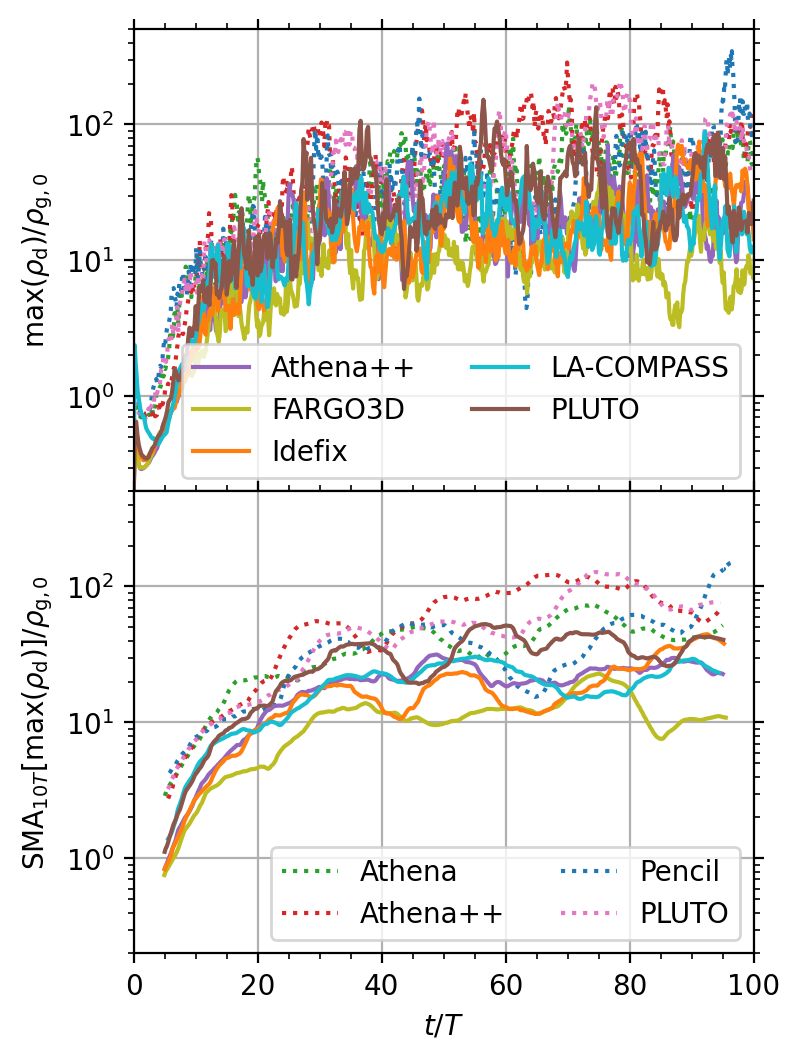

In [2]:
#===============================================================================
def print_samples(code, t, step, dt, window):
    """Print the number of samples in the time series."""
    print(f'{code} samples\n=======================')
    print(f'\t  Total: {len(t)}')
    print(f'\tStrided: {len(t[::step])}')
    print(f'\tPer {dt}T: {window}')

diag = True
dt = 10  # [T]

# Lowest cadence
path = f'{root}/dust_fluid/FARGO3D'
n_min = len(np.load(f'{path}/time_series.npz')['t'])

# Plot
fig, axs = plt.subplots(nrows=2, sharex=True, figsize=(4, 6), dpi=200)
for k, (key, value) in enumerate(runs.items()):
    for code, color in value['codes'].items():
        path = f'{root}/{key}/{code}'
        data = np.load(f'{path}/time_series.npz')
        t = data['t']
        # Strided
        step = len(t)//n_min
        if step < 2:
            step = 1 if len(t)%n_min/n_min < 0.5 else 2
        try:
            axs[0].plot(t[::step], data['maxrhod'][::step], c=color,
                        ls=value['ls'])
        except KeyError:
            print(code)
        # SMA
        window = len(t)//int(t[-1]/dt)
        print_samples(code, t, step, dt, window) if diag else None
        df = pd.DataFrame(data=data['maxrhod'], index=t)
        df['sma'] = df.rolling(window, center=True).mean()
        axs[1].plot(df['sma'], c=color, ls=value['ls'])
        axs[k-1].plot([], [], c=color, label=code, ls=value['ls'])

# Format plots
for ax in axs:
    ax.grid()
    ax.legend(ncol=2)
    ax.minorticks_on()
    ax.set(yscale='log')
    ax.tick_params(axis='both', which='both', top=True, right=True)
axs[0].set(ylabel=rf'$\max(\rho_\mathrm{{d}})/\rho_\mathrm{{g,0}}$', ylim=(2e-1, 5e2))
axs[1].set(xlabel=r'$t/T$', xlim=(0, 100), ylim=(2e-1, 5e2),
           ylabel=rf'$\mathrm{{SMA}}_{{{dt}T}}[\max(\rho_\mathrm{{d}})]/\rho_\mathrm{{g,0}}$')
fig.subplots_adjust(hspace=0)